<a href="https://www.kaggle.com/code/vedantbhavsar43/delhi-house-data-outliers-detection?scriptVersionId=336154258" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vedantbhavsar43/gurgaon-house-data-v2/gurgaon_properties_cleaned_v2.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/vedantbhavsar43/gurgaon-house-data-v2/gurgaon_properties_cleaned_v2.csv")

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


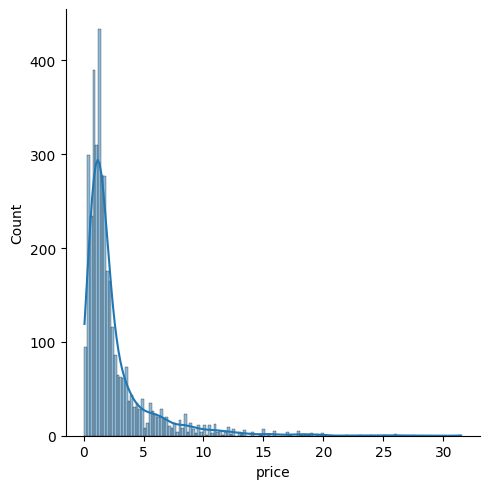

In [4]:
sns.displot(df['price'], kde=True)

<Axes: xlabel='price'>

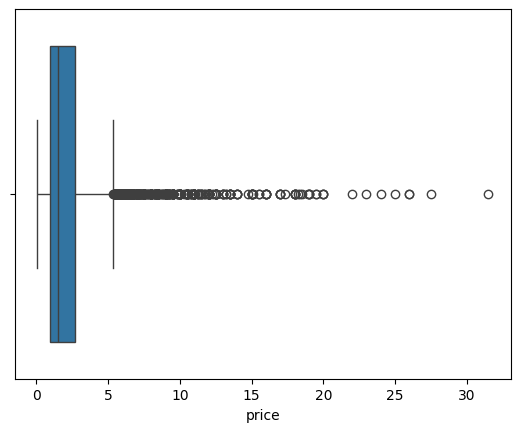

In [5]:
sns.boxplot(x=df['price'])

In [6]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]

outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(432,
 count    432.000000
 mean       9.196157
 std        4.061291
 min        5.350000
 25%        6.400000
 50%        8.000000
 75%       10.607500
 max       31.500000
 Name: price, dtype: float64)

In [7]:
outliers.sort_values(by='price',ascending=True).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1605,house,bptp visionnaire,sector 70a,5.35,8916.0,6000.0,Built Up area: 6000 (557.42 sq.m.),4,4,3+,...,NaN,6000.00,NaN,1,1,1,1,0,1,160
480,house,bptp visionnaire,sector 70a,5.40,20690.0,2610.0,Plot area 290(242.48 sq.m.),4,5,3+,...,NaN,2610.00,NaN,1,1,1,1,0,1,136
717,flat,m3m golfestate,sector 65,5.40,18126.0,2979.0,Super Built up area 2979(276.76 sq.m.),3,4,3,...,2979.0,NaN,NaN,1,1,0,0,0,1,174
1772,house,ansal api esencia,sector 67,5.46,24170.0,2259.0,Plot area 251(209.87 sq.m.),4,5,3+,...,NaN,2259.00,NaN,1,0,1,1,0,1,103
289,flat,experion windchants,sector 112,5.49,11584.0,4739.0,Super Built up area 4739(440.27 sq.m.)Built Up...,4,5,3+,...,4739.0,3655.35,NaN,0,1,0,0,0,1,168
1894,flat,krrish provence estate,gwal pahari,5.50,9482.0,5800.0,Super Built up area 5800(538.84 sq.m.),4,5,3+,...,5800.0,NaN,NaN,1,1,0,1,0,0,151
2179,house,dlf city phase 1,sector 26,5.50,30556.0,1800.0,Plot area 200(167.23 sq.m.),4,4,3+,...,NaN,1800.00,NaN,0,0,1,1,0,0,49
153,flat,m3m golfestate,sector 65,5.50,16959.0,3243.0,Super Built up area 3243(301.28 sq.m.)Built Up...,3,4,3,...,3243.0,2803.00,2388.0,0,1,0,0,0,0,49
742,house,independent,sector 23,5.50,21825.0,2520.0,Plot area 280(234.12 sq.m.),8,8,2,...,NaN,2520.00,NaN,1,1,0,1,0,1,76
1607,flat,raheja atlantis,sector 31,5.50,18688.0,2943.0,Super Built up area 2943(273.41 sq.m.),4,5,3+,...,2943.0,NaN,NaN,1,1,0,1,0,0,81


In [8]:
outliers.sort_values(by='price',ascending=True).tail(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
426,house,independent,sector 26,18.25,18250.0,10000.0,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,...,NaN,NaN,10000.0,1,1,1,1,0,1,77
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,...,NaN,NaN,11000.0,0,1,1,1,0,1,60
2739,house,vipul tatvam villa,sector 48,18.50,26428.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,1,...,NaN,7000.0,NaN,0,0,0,0,0,0,30
2003,house,independent,sector 26,18.90,41833.0,4518.0,Plot area 502(419.74 sq.m.),6,8,2,...,NaN,4518.0,NaN,1,1,1,1,0,1,120
1526,house,dlf city plots,sector 26,19.00,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,...,NaN,4518.0,NaN,1,1,0,0,0,1,121
550,house,emaar mgf marbella,sector 66,19.00,31666.0,6000.0,Plot area 9000(836.13 sq.m.)Carpet area: 6000 ...,5,6,3+,...,NaN,NaN,6000.0,0,1,1,1,0,1,110
2130,house,independent,sector 26,19.00,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,...,NaN,4500.0,NaN,1,1,1,1,0,1,103
966,house,vipul tatvam villa,sector 48,19.50,22222.0,8775.0,Plot area 975(815.22 sq.m.),5,6,3,...,NaN,8775.0,NaN,1,1,1,1,0,1,110
1687,house,independent,sector 2,19.50,27083.0,7200.0,Plot area 800(668.9 sq.m.),8,9,3+,...,NaN,7200.0,NaN,1,1,0,1,0,0,122
2096,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,...,NaN,500.0,NaN,0,1,0,0,0,1,31


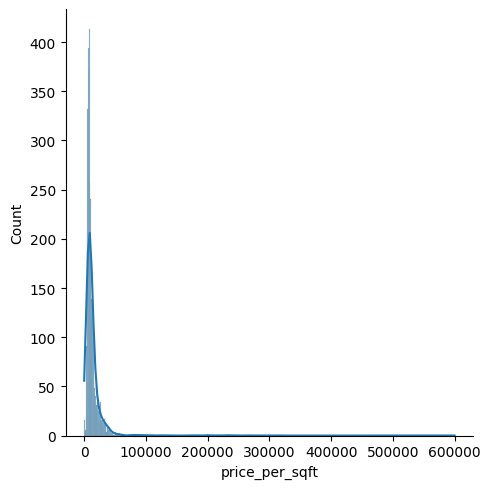

In [9]:
sns.displot(df['price_per_sqft'], kde=True)

<Axes: xlabel='price_per_sqft'>

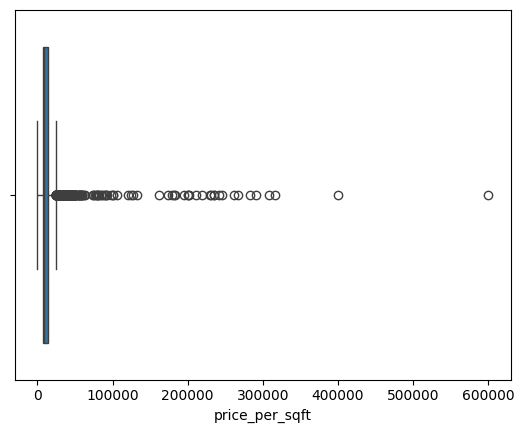

In [10]:
sns.boxplot(x=df['price_per_sqft'])

In [11]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

pps_outliers = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]
num_outliers = pps_outliers.shape[0]
pps_outliers['price_per_sqft'].describe()

count       367.000000
mean      52115.435967
std       60746.225927
min       24202.000000
25%       27778.000000
50%       33333.000000
75%       41790.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

- Here we can see there is mean 52115 it is too higher
- Max value is 60000 so here data containes some extreme outliers

let's export this data in .xlsx so we can manually identify patterns

### Here we find that the ouliers actually calculation mistake like `price_per_sqft = (Price*10000000)/Area in SQFT` (But Here the area unit is SQYard) So  We have to convert it into `SQFT by multiplying 9`

**Here we find a pattern that if area(SQYard) is less then 1000 then the price becomes outlier**

In [12]:
pps_outliers = pps_outliers.sort_values(by='price_per_sqft', ascending=False)

In [13]:
pps_outliers[['price_per_sqft','area']].head(15)

,price_per_sqft,area
3046,600000.0,400.0
2850,400000.0,250.0
2461,315789.0,190.0
2047,308333.0,60.0
975,290948.0,232.0
342,283333.0,251.0
3449,266666.0,300.0
2161,261194.0,402.0
3519,245398.0,175.0
2277,241666.0,60.0


In [14]:
pps_outliers['area'] = pps_outliers['area'].apply(lambda x: x*9 if x<1000 else x)

In [15]:
pps_outliers['price_per_sqft'] = round((pps_outliers['price']*10000000)/(pps_outliers['area']))

In [16]:
pps_outliers['price_per_sqft'].head(20)

3046    66667.0
2850    44444.0
2461    35088.0
2047    34259.0
975     32328.0
342     31430.0
3449    29630.0
2161    29022.0
3519    27302.0
2277    26852.0
3015    26153.0
3356    26042.0
3386    25616.0
545     25543.0
2004    24306.0
1027    23457.0
1259    22377.0
3090    22222.0
2418    22222.0
2738    21605.0
Name: price_per_sqft, dtype: float64

In [17]:
pps_outliers['price_per_sqft'].describe()

count      367.000000
mean     29160.735695
std      12308.413881
min       2689.000000
25%      25051.500000
50%      29630.000000
75%      35489.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

From `mean: 50000` it becomes `28641` now the mean and median are closer

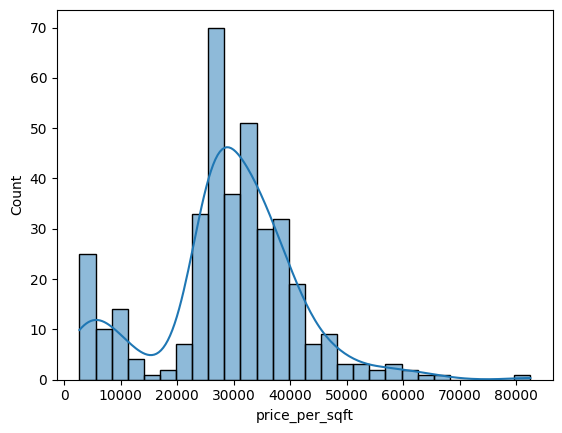

In [18]:
sns.histplot(pps_outliers['price_per_sqft'], kde=True)
plt.show()

In [19]:
pps_outliers['price_per_sqft'].skew()

np.float64(-0.07304178994356218)

<Axes: xlabel='price_per_sqft'>

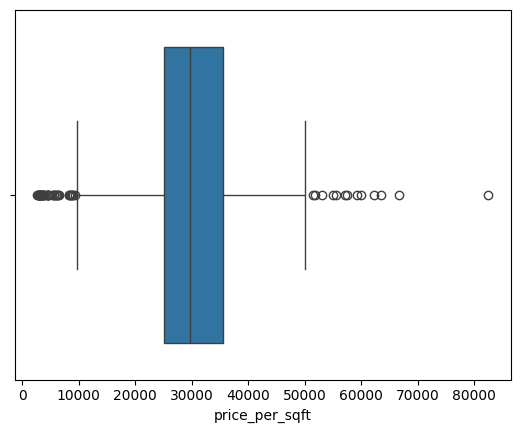

In [20]:
sns.boxplot(x=pps_outliers['price_per_sqft'])

In [21]:
pps_outliers['area'].describe()

count      367.000000
mean      2878.272480
std       1688.158877
min        450.000000
25%       1800.000000
50%       2475.000000
75%       3281.500000
max      11286.000000
Name: area, dtype: float64

In [22]:
df.update(pps_outliers)

In [23]:
df['price_per_sqft'].sort_values(ascending=False).head(10)

2211    82540.0
3046    66667.0
1425    63492.0
1640    62222.0
1839    60000.0
1261    59259.0
1349    57508.0
2488    57206.0
671     55556.0
386     55000.0
Name: price_per_sqft, dtype: float64

In [24]:
df = df[df['price_per_sqft'].notna()]

In [25]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


<Axes: xlabel='area'>

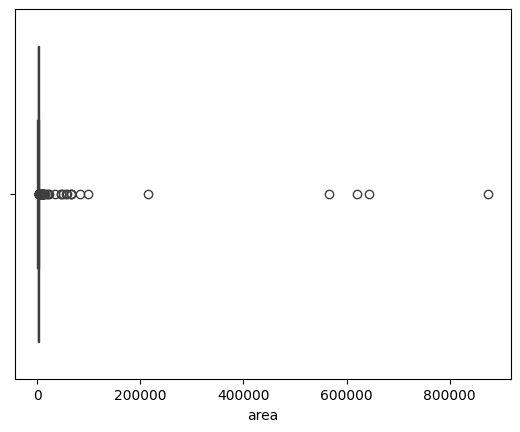

In [26]:
sns.boxplot(x=df['area'])

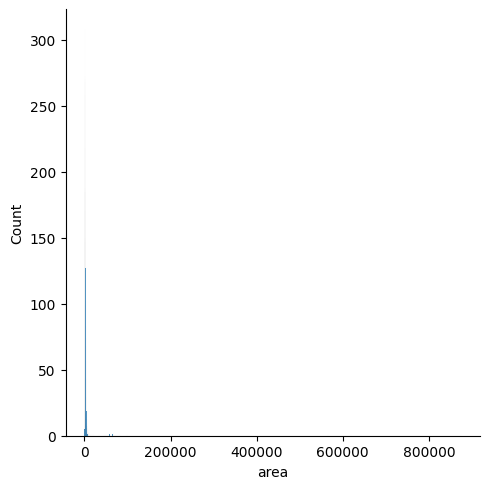

In [27]:
sns.displot(df['area'])

In [28]:
df['area'].describe()

count      3785.000000
mean       2905.157199
std       22783.155799
min         145.000000
25%        1259.000000
50%        1745.000000
75%        2341.000000
max      875000.000000
Name: area, dtype: float64

In [29]:
df = df[df['area'] < 100000]

In [30]:
df[df['area'] > 10000]


# 2, 115, 1123, 181, 1471, 1796, 2356, 2503, 3649

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.00,0,0,0,0,0,0,15
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,0,7
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,...,NaN,NaN,48811.00,1,0,0,0,0,0,37
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,0,0
747,house,independent,sohna road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,...,NaN,3500.0,NaN,1,1,0,1,1,0,49
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,...,NaN,NaN,11000.00,0,1,1,1,0,1,60
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,...,NaN,NaN,64412.00,0,0,0,0,0,0,51
1358,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,...,NaN,2660.0,2500.00,0,1,0,0,0,1,61
1471,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,...,NaN,13500.0,NaN,0,0,0,0,1,0,0
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,...,NaN,NaN,64529.00,1,0,0,0,0,0,15


In [31]:
df.shape[0]

3780

In [32]:
df.drop([2, 115, 1123, 818, 1471, 1796, 2356, 2503, 3649], inplace=True)

In [33]:
df.shape[0]

3771

In [34]:
df[df['area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,0,7
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,0,0
747,house,independent,sohna road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,...,NaN,3500.0,NaN,1,1,0,1,1,0,49
1358,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,...,NaN,2660.0,2500.00,0,1,0,0,0,1,61
2131,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.00,1,0,0,1,1,1,44
2342,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.00,0,1,0,0,0,0,60
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,...,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42
3088,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,...,NaN,2160.0,1720.00,0,1,0,0,0,0,160
3195,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,...,NaN,2850.0,2250.00,1,1,0,1,1,1,123


In [35]:
df.loc[48, 'area'] = 115*9
df.loc[300, 'area'] = 7250
df.loc[2666, 'area'] = 5800
df.loc[1358, 'area'] = 2660
df.loc[3195, 'area'] = 2850
df.loc[2131, 'area'] = 1812
df.loc[3088, 'area'] = 2160
df.loc[3444, 'area'] = 1175

In [36]:
502*9

4518

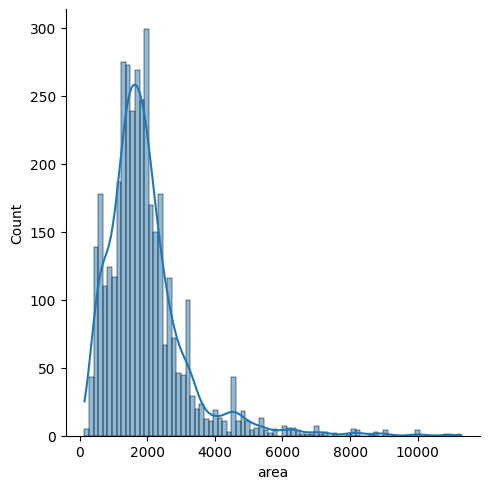

In [37]:
sns.displot(df['area'], kde=True)

In [38]:
df.area.describe()

count     3771.000000
mean      1944.131265
std       1213.337502
min        145.000000
25%       1253.500000
50%       1743.000000
75%       2320.500000
max      11286.000000
Name: area, dtype: float64

<Axes: xlabel='area'>

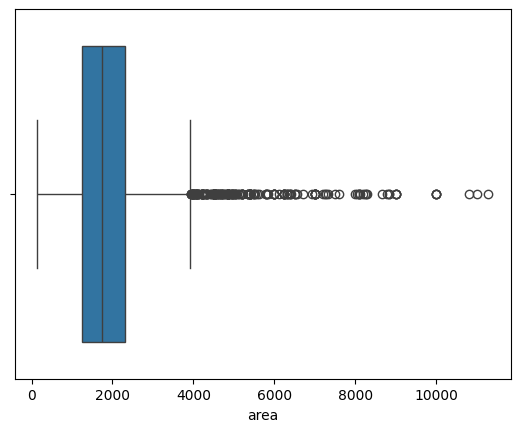

In [39]:
sns.boxplot(x=df['area'])

In [40]:
df[df['area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
747,house,independent,sohna road,5.5,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,...,NaN,3500.0,NaN,1,1,0,1,1,0,49
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,0,60
2834,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42


In [41]:
df['price_per_sqft'] = (df['price']*10000000)/(df['area'])

In [42]:
df.area.describe()

count     3771.000000
mean      1944.131265
std       1213.337502
min        145.000000
25%       1253.500000
50%       1743.000000
75%       2320.500000
max      11286.000000
Name: area, dtype: float64

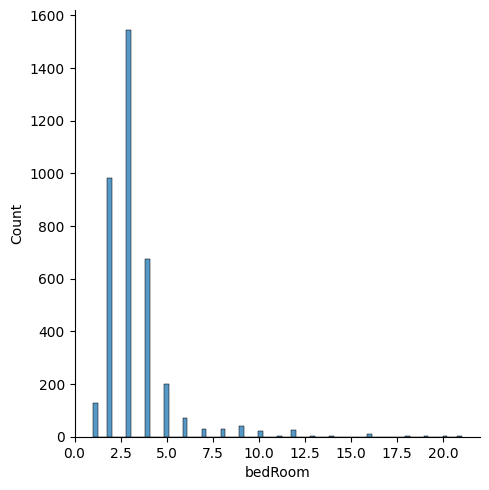

In [43]:
sns.displot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

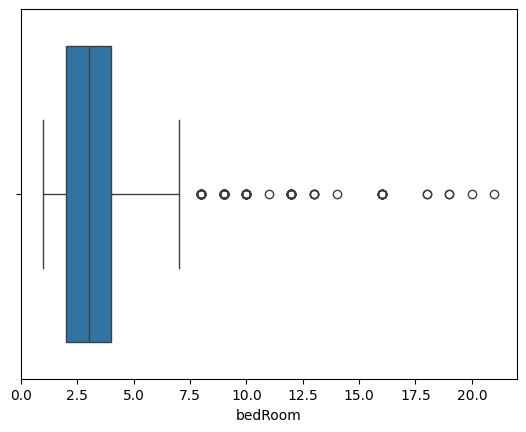

In [44]:
sns.boxplot(x=df['bedRoom'])

In [45]:
df['bedRoom'].describe()

count    3771.000000
mean        3.328825
std         1.859969
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [46]:
df[df['bedRoom'] > 10].sort_values(by='bedRoom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3618,house,independent,sector 54,5.00,43066.322136,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,...,NaN,1161.0,NaN,0,1,0,0,0,2,49
2611,house,independent,sector 43,4.50,39062.500000,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,...,NaN,1152.0,NaN,0,1,0,0,0,2,22
78,house,independent,sector 17,3.87,5160.000000,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,...,NaN,7500.0,NaN,1,0,1,0,0,0,68
1493,house,independent,sector 17,3.93,24214.417745,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,...,NaN,1622.0,NaN,1,1,1,1,0,0,74
1381,house,private house,sector 55,7.05,46906.187625,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,...,NaN,1503.0,NaN,0,0,0,0,1,2,57
19,house,independent,sector 54,5.50,38194.444444,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,...,NaN,1440.0,NaN,0,1,0,0,0,2,70
1261,house,independent,sector 25,16.00,59259.259259,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,...,NaN,325.0,300.0,1,1,1,1,0,2,72
1200,house,independent,sector 26,14.75,51863.572433,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,...,NaN,2844.0,NaN,1,1,1,1,0,1,153
874,house,dlf city plots,sector 26,20.00,44267.374945,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,...,NaN,4518.0,NaN,1,1,1,1,0,1,153
372,house,independent,sector 11,4.50,25000.000000,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,...,NaN,1800.0,NaN,0,0,0,0,0,1,20


In [47]:
df = df[df['bedRoom'] <= 10]

In [48]:
df.shape

(3721, 23)

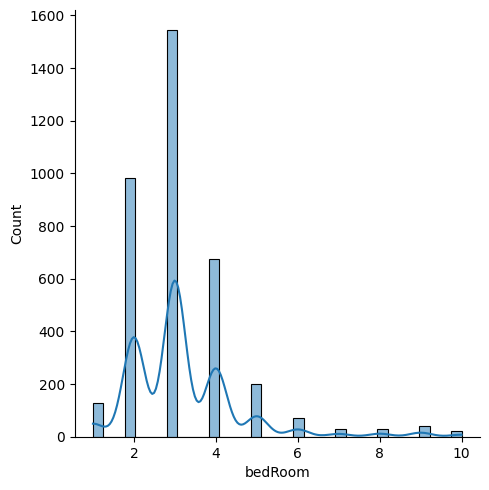

In [49]:
sns.displot(df['bedRoom'], kde=True)

<Axes: xlabel='bedRoom'>

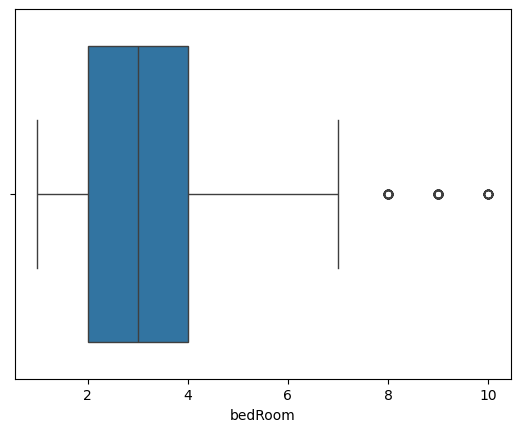

In [50]:
sns.boxplot(x=df['bedRoom'])

In [51]:
df.bedRoom.describe()

count    3721.000000
mean        3.187584
std         1.382792
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

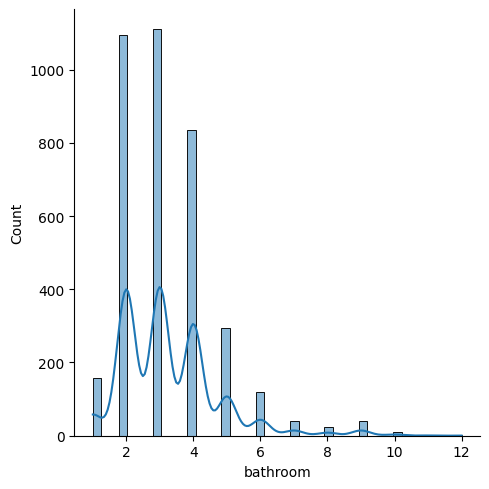

In [52]:
sns.displot(df['bathroom'], kde=True)

<Axes: xlabel='bathroom'>

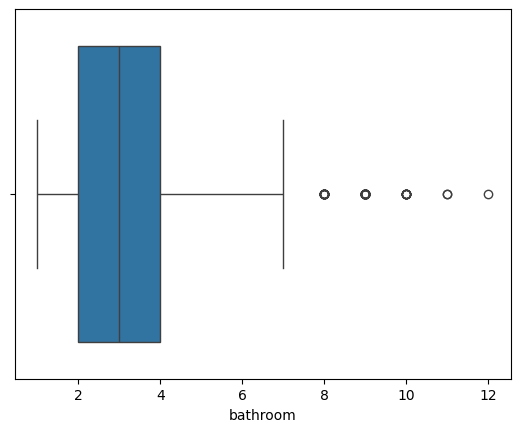

In [53]:
sns.boxplot(x=df['bathroom'])

In [54]:
df[df['bathroom'] > 10].sort_values('bathroom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3267,house,adani brahma samsara,sector 60,18.02,28200.312989,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,...,NaN,6390.0,NaN,0,1,0,0,0,1,146
2771,house,independent,sector 39,7.00,10000.000000,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,...,NaN,7000.0,NaN,0,0,0,1,0,2,38
2816,house,independent,sector 24,11.00,28901.734104,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,...,NaN,5000.0,NaN,1,1,0,1,1,1,39


**Here this value looks genuine so we will keep them**

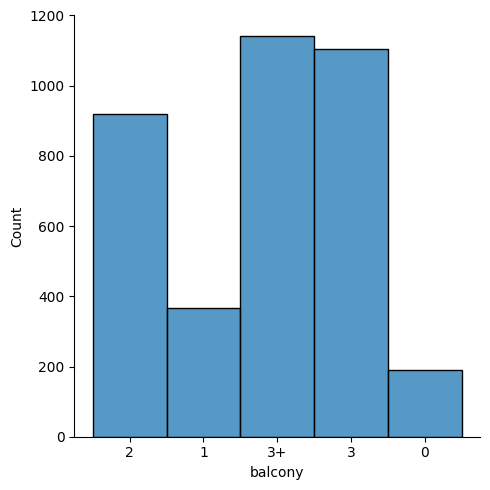

In [55]:
sns.displot(df['balcony'])

**For now lets keep balcony**

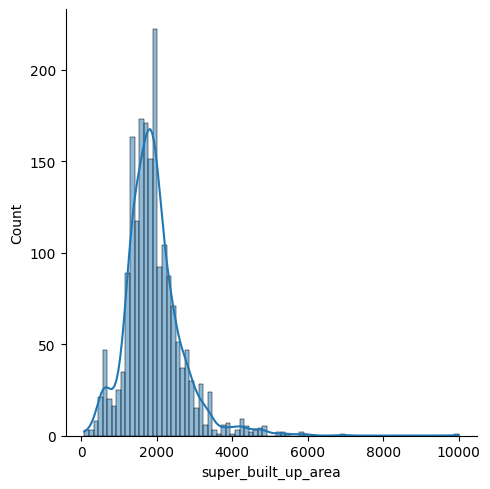

In [56]:
sns.displot(df['super_built_up_area'], kde=True)

<Axes: xlabel='super_built_up_area'>

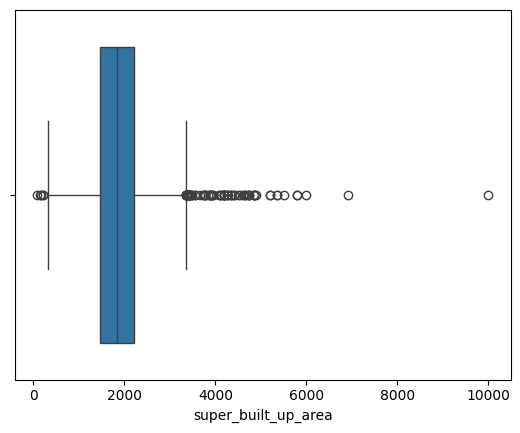

In [57]:
sns.boxplot(x=df['super_built_up_area'])

In [58]:
df['super_built_up_area'].describe()

count     1915.000000
mean      1921.658251
std        767.160169
min         89.000000
25%       1457.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [59]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1323,flat,bestech park view grand spa,sector 81,4.7,6786.023679,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,...,6926.0,NaN,NaN,0,1,0,0,0,1,140
3265,flat,krrish provence estate,gwal pahari,7.5,7500.000000,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,...,10000.0,NaN,NaN,0,1,0,1,1,0,49


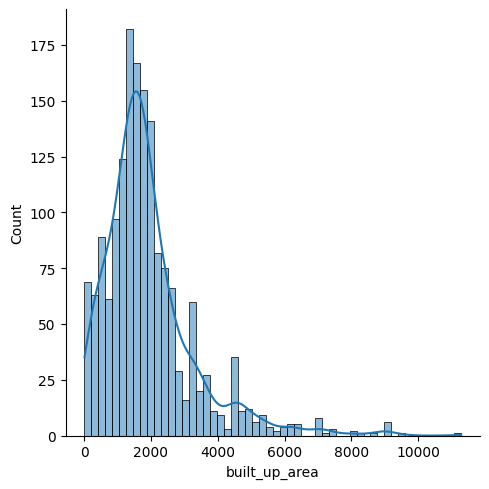

In [60]:
sns.displot(df['built_up_area'], kde=True)

<Axes: xlabel='built_up_area'>

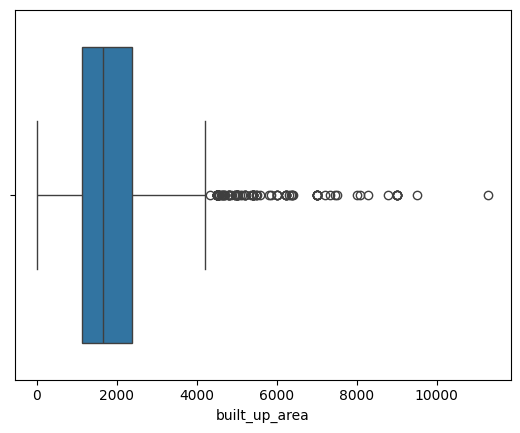

In [61]:
sns.boxplot(x=df['built_up_area'])

In [62]:
df[df['built_up_area'] > 6000].sort_values('built_up_area', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2834,house,independent,sector 43,27.50,24366.471735,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42
114,house,independent,sector 25,10.00,37037.037037,2700.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,...,NaN,9500.0,9000.0,0,1,0,1,0,2,29
2765,house,independent,sector 26,23.00,25555.555556,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,9000.0,NaN,1,1,1,1,0,1,145
323,house,anamika enclave,sector 12,6.00,14492.753623,4140.0,Plot area 4140(384.62 sq.m.)Built Up area: 900...,9,9,3+,...,NaN,9000.0,NaN,0,0,0,0,0,0,9
1971,house,dlf alameda,sector 73,17.00,35109.458901,4842.0,Plot area 4842(449.84 sq.m.)Built Up area: 900...,5,8,3,...,NaN,9000.0,NaN,1,1,1,1,0,2,87
821,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.000000,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,...,NaN,9000.0,NaN,1,1,1,1,0,2,74
1325,house,ansal sushant lok plots,sector 43,11.50,17692.307692,6500.0,Plot area 3762(349.5 sq.m.)Built Up area: 9000...,7,8,3+,...,NaN,9000.0,6500.0,0,1,1,1,0,1,31
3647,house,independent,sohna road,6.25,6943.672925,9001.0,Plot area 1000(836.13 sq.m.),3,3,0,...,NaN,9000.0,NaN,0,0,0,0,0,0,0
966,house,vipul tatvam villa,sector 48,19.50,22222.222222,8775.0,Plot area 975(815.22 sq.m.),5,6,3,...,NaN,8775.0,NaN,1,1,1,1,0,1,110
2432,house,independent,sector 56,8.00,9653.674430,8287.0,Plot area 362(33.63 sq.m.)Built Up area: 8286 ...,10,10,3+,...,NaN,8286.0,NaN,1,1,0,1,0,2,107


**This are acceptable values we can keep this**

In [63]:
df['built_up_area'].describe()

count     1663.000000
mean      1928.926861
std       1387.365360
min         14.000000
25%       1120.000000
50%       1650.000000
75%       2367.000000
max      11286.000000
Name: built_up_area, dtype: float64

In [64]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2834,house,independent,sector 43,27.5,24366.471735,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42


**If we porsonally focus on this sample we can see that its a extream value but we can't directy remove it.**

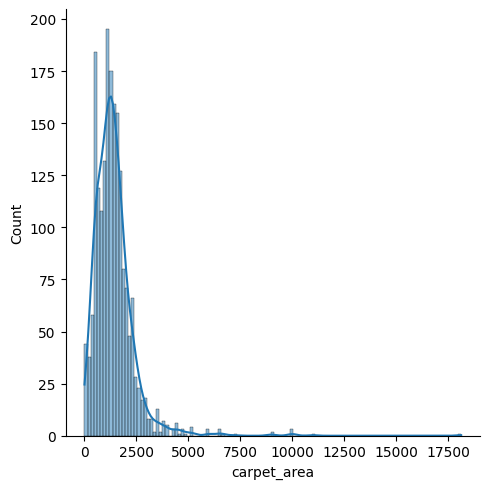

In [65]:
sns.displot(df['carpet_area'], kde=True)

<Axes: xlabel='carpet_area'>

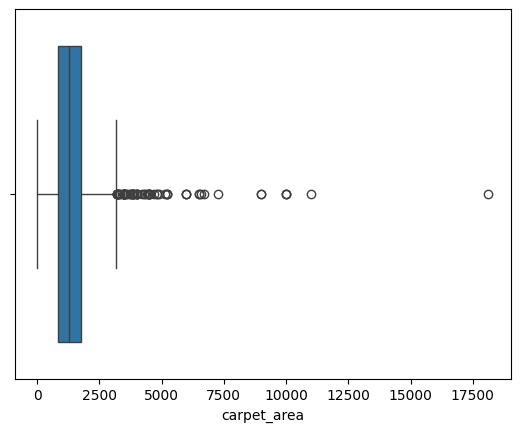

In [66]:
sns.boxplot(x=df['carpet_area'])

In [67]:
df['carpet_area'].describe()

count     1923.000000
mean      1427.642006
std       1036.039780
min         15.000000
25%        830.000000
50%       1290.000000
75%       1762.000000
max      18122.000000
Name: carpet_area, dtype: float64

In [68]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2131,flat,godrej air,sector 85,2.5,13796.909492,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.0,1,0,0,1,1,1,44
2342,flat,m3m golfestate,sector 65,13.2,12000.000000,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [69]:
df.loc[2131, 'carpet_area'] = 8122

In [70]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [71]:
df.luxury_score.describe()

count    3721.000000
mean       71.236496
std        53.031082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

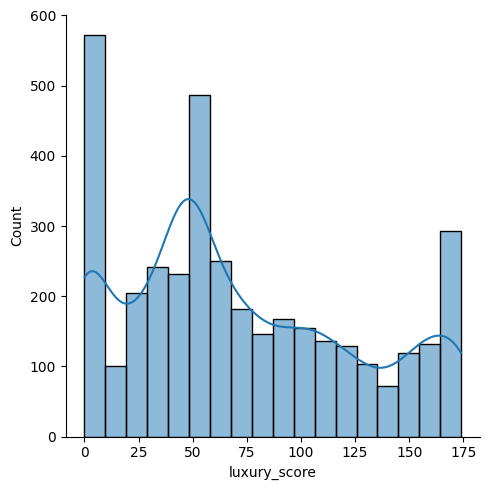

In [72]:
sns.displot(df.luxury_score, kde=True)

<Axes: xlabel='luxury_score'>

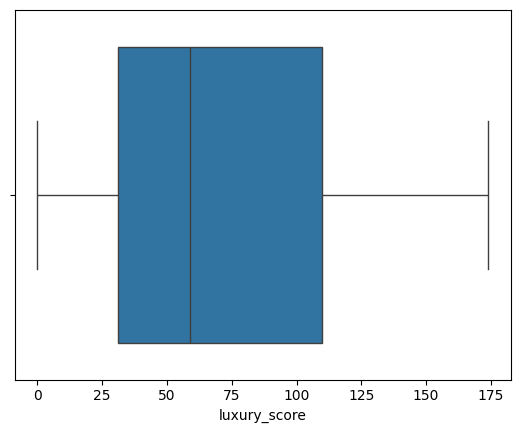

In [73]:
sns.boxplot(x=df.luxury_score)

In [74]:
df[df['luxury_score'] > 150]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,flat,bestech park view sanskruti,sector 92,1.60,8020.050125,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174
5,flat,suncity avenue,sector 102,0.48,9022.556391,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,...,632.0,NaN,532.0,0,0,1,0,0,0,159
8,flat,adani m2k oyster grande,sector 102,1.90,9103.977000,2087.0,Super Built up area 1889(175.49 sq.m.),3,4,3,...,1889.0,NaN,NaN,0,1,0,0,0,0,165
14,flat,emaar mgf emerald floors premier,sector 65,2.77,14025.316456,1975.0,Carpet area: 1975 (183.48 sq.m.),4,4,3+,...,NaN,NaN,1975.0,1,1,0,0,0,2,174
17,flat,ss the leaf,sector 85,1.09,6666.666667,1635.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,1640.0,1638.0,1635.0,0,0,1,0,0,0,174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3767,flat,ss the leaf,sector 85,1.93,8075.313808,2390.0,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,...,2408.0,2400.0,2390.0,0,1,0,0,0,0,174
3772,flat,indiabulls centrum park,sector 103,1.15,8679.245283,1325.0,Super Built up area 1325(123.1 sq.m.)Carpet ar...,2,2,3,...,1325.0,NaN,865.0,1,0,0,0,0,1,174
3773,flat,emaar mgf the enclave,sector 66,1.90,10555.555556,1800.0,Super Built up area 1920(178.37 sq.m.)Built Up...,3,4,2,...,1920.0,1850.0,1800.0,0,1,0,0,0,1,174
3796,flat,paras dews,sector 106,0.92,6642.599278,1385.0,Super Built up area 1385(128.67 sq.m.)Built Up...,2,2,3+,...,1385.0,940.0,845.0,0,0,0,0,0,0,174


In [75]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(257.0)

In [76]:
df[(df['area']/df['bedRoom']) < 250].sample(5), df['area']/df['bedRoom']

(     property_type            society      sector  price  price_per_sqft  \
 1167         house        independent   sector 13   0.90    11464.968153   
 663           flat  conscient habitat   sector 99   0.27     5601.659751   
 1480         house         huda floor   sector 38   4.00    22222.222222   
 1627         house        independent  sector 105   0.55    10912.698413   
 2386         house        independent   sector 47   4.60    26620.370370   
 
         area                                       areaWithType  bedRoom  \
 1167   785.0                         Plot area 785(72.93 sq.m.)        5   
 663    482.0                     Carpet area: 484 (44.97 sq.m.)        2   
 1480  1800.0  Plot area 1800(167.23 sq.m.)Built Up area: 480...        9   
 1627   504.0                      Built Up area: 56 (5.2 sq.m.)        4   
 2386  1728.0                        Plot area 192(160.54 sq.m.)        7   
 
       bathroom balcony  ...  super_built_up_area built_up_area carpet_a

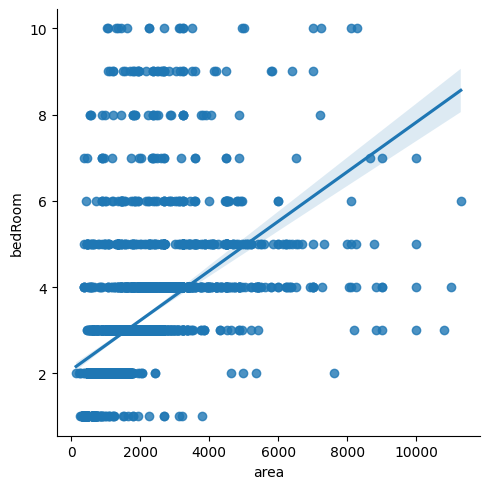

In [77]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [78]:
df['area_to_bedRoom_ratio'] = df['area']/df['bedRoom']

In [79]:
df[(df['area_to_bedRoom_ratio'] < 250) & (df['bedRoom'] > 3)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_to_bedRoom_ratio
9,house,independent,sector 105,1.20,10118.043845,1186.0,Plot area 1185.51(110.14 sq.m.),6,2,1,...,1185.51,NaN,0,0,0,0,0,0,9,197.666667
15,house,independent,sector 12,1.20,14184.397163,846.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq...,4,4,2,...,846.00,NaN,0,0,0,1,0,1,7,211.500000
37,house,independent,sector 104,0.45,12162.162162,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4,4,2,...,NaN,1500.0,0,0,0,0,0,1,7,92.500000
48,house,ganpati heights apartment,sector 13,1.25,12077.294686,1035.0,Plot area 115(7692.86 sq.m.),10,6,2,...,115.00,NaN,0,0,0,0,1,0,7,103.500000
74,house,independent,sector 25,7.60,38755.736869,1961.0,Plot area 215(179.77 sq.m.),9,9,3,...,1935.00,NaN,1,0,1,1,0,1,84,217.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3686,house,independent,sector 12,0.90,13333.333333,675.0,Built Up area: 675 (62.71 sq.m.),4,4,0,...,675.00,NaN,0,0,0,0,0,0,0,168.750000
3713,house,independent,sector 41,4.25,26234.567901,1620.0,Plot area 180(150.5 sq.m.),10,9,3+,...,1620.00,NaN,1,1,0,0,0,1,36,162.000000
3738,house,independent,sector 7,1.16,11693.548387,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,5,4,2,...,NaN,992.0,0,0,0,0,1,0,39,198.400000
3774,house,independent,sector 28,0.45,10000.000000,450.0,Built Up area: 50 (4.65 sq.m.),5,3,0,...,50.00,NaN,0,0,0,0,0,0,0,90.000000
